In [11]:
%matplotlib inline

from pathlib import Path
import json
import re
import time
import subprocess
import sys
from itertools import combinations
from typing import List, Dict, Any, Iterable, Set

import networkx as nx
import matplotlib.pyplot as plt

try:
    from pypdf import PdfReader
except Exception:
    PdfReader = None

try:
    import spacy
    HAS_SPACY = True
except Exception:
    HAS_SPACY = False

# Configuration (simple, PT-BR focused)
RAW_DIR = Path("../data/raw").resolve()
PROCESSED_DIR = Path("../data/processed").resolve()
OUTPUT_DIR = Path("../output").resolve()
DEFAULT_SPACY_MODEL = "pt_core_news_sm"
MODEL_CANDIDATES = ["pt_core_news_lg", "pt_core_news_sm"]
ENTITIES_PER_DOC = 10
FILE_LIMIT = 5
FILTER_LABELS = {"PERSON", "PER", "ORG", "GPE", "LOC"}
CHAR_BLOCK_SIZE = 500

# Common paths used by other cells
PROCESSED_RAW_TEXTS = PROCESSED_DIR / "raw_texts"
ENTITIES_JSONL = PROCESSED_DIR / "entities.jsonl"
PERF_METRICS = PROCESSED_DIR / "performance_metrics.json"

# Ensure directories exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_RAW_TEXTS.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def clean_text(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def extract_pdf_text(pdf_path: Path) -> str:
    if PdfReader is None:
        raise RuntimeError("pypdf is not available in this environment")
    pages: List[str] = []
    try:
        reader = PdfReader(str(pdf_path))
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                pages.append(page_text)
    except Exception as e:
        print(f"[ERROR] Failed reading {pdf_path.name}: {e}")
        return ""
    return clean_text("\n\n".join(pages))


def get_nlp(candidates=MODEL_CANDIDATES):
    if not HAS_SPACY:
        raise RuntimeError("spaCy is not installed in this environment")
    for m in candidates:
        try:
            nlp = spacy.load(m, exclude=["parser", "attribute_ruler", "lemmatizer", "tagger"])
            if "sentencizer" not in nlp.pipe_names:
                nlp.add_pipe("sentencizer")
            return nlp
        except Exception:
            continue
    # Try to download the default model and load it
    subprocess.run([sys.executable, "-m", "spacy", "download", DEFAULT_SPACY_MODEL], check=True)
    nlp = spacy.load(DEFAULT_SPACY_MODEL, exclude=["parser", "attribute_ruler", "lemmatizer", "tagger"])
    if "sentencizer" not in nlp.pipe_names:
        nlp.add_pipe("sentencizer")
    return nlp


def extract_limited_entities_from_doc(doc, max_entities=ENTITIES_PER_DOC, filter_labels=FILTER_LABELS):
    ents = []
    for ent in getattr(doc, "ents", []):
        txt = getattr(ent, "text", "")
        if not txt or not txt.strip():
            continue
        txt = txt.strip().lower()
        label = getattr(ent, "label_", None)
        if filter_labels and label and label.upper() not in {fl.upper() for fl in filter_labels}:
            continue
        ents.append(txt)
    seen = set(); out = []
    for e in ents:
        if e not in seen:
            seen.add(e); out.append(e)
        if len(out) >= max_entities:
            break
    return set(out)


def append_entities_jsonl(record_id, entities, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        json.dump({"id": record_id, "entities": sorted(list(entities))}, f, ensure_ascii=False)
        f.write("\n")


def segment_text_by_paragraph(text: str) -> List[str]:
    return [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]

def segment_text_by_char_blocks(text: str, size: int) -> List[str]:
    s = text.strip()
    if not s:
        return []
    return [s[i:i+size] for i in range(0, len(s), size)]

print("Setup complete — change FILE_LIMIT at the top to control how many files are processed")

Setup complete — change FILE_LIMIT at the top to control how many files are processed


## Stage 0 — Environment & Imports

This stage configures constants, imports required libraries and shows an optional install cell. Modify `FILE_LIMIT` to control how many files the notebook will actually read.

# Graph-NER — Staged pipeline (limit files)

This notebook reproduces the core Graph-NER pipeline in small, testable stages and enforces a strict cap on how many files are read. Change `FILE_LIMIT` near the top to control how many documents the notebook will open and process.

In [12]:
# Setup moved to the first cell. Run the first code cell to initialize configuration and helpers.
print("Run cell 1 (Setup) before running stages.")

Run cell 1 (Setup) before running stages.


## Stage 1 — Discover files (limit & preview)

This cell discovers PDF files under `RAW_DIR` but stops early to enforce the discovery cap. It does not open the files — only metadata is collected.

In [13]:
def list_files(path: Path, pattern: str = "*.pdf", limit: int = 100) -> List[Path]:
    results: List[Path] = []
    if not path.exists():
        return results
    for p in sorted(path.glob(pattern)):
        results.append(p)
        if len(results) >= limit:
            break
    return results

pdf_files = list_files(RAW_DIR, "*.pdf", FILE_LIMIT)
print(f"Discovered {len(pdf_files)} PDFs (capped at FILE_LIMIT={FILE_LIMIT})")
for p in pdf_files:
    print("-", p.name)

Discovered 5 PDFs (capped at FILE_LIMIT=5)
- AplicaçãoDeEstencilsCompactos_Freire_2025.pdf
- Arquitetura_de_Monitoramento_e_Observabilidade_de_Aplicações_em_Kubernetes (13).pdf
- Augusto Damasceno - TCC - Pub.pdf
- EstudoComparativoVariantes_Freire_2025.pdf
- Hora769rios_e_dias_da_arguic807a771o_oral_-_Polo_RN.pdf


## Stage 2 — Extract text (limited)

This stage extracts text from the discovered PDFs but only processes the first `FILE_LIMIT` files. Text for each processed file is saved to `data/processed/raw_texts/`.

In [14]:
records: List[Dict[str, Any]] = []
for p in pdf_files:
    txt = extract_pdf_text(p)
    if not txt:
        print(f"[WARN] No text for {p.name}")
        continue
    rec = {"id": p.stem, "title": p.stem, "text": txt, "path": str(p)}
    records.append(rec)
    # save raw text per file
    out_path = PROCESSED_RAW_TEXTS / f"{rec['id']}.txt"
    with out_path.open("w", encoding="utf-8") as f:
        f.write(txt)

print(f"Extracted and saved raw text for {len(records)} documents (limited)")
if records:
    print("Sample text (first 400 chars):\n", records[0]["text"][:400])

Multiple definitions in dictionary at byte 0x97a for key /Group
Multiple definitions in dictionary at byte 0x4bc0b2 for key /Group
Multiple definitions in dictionary at byte 0x53bc52 for key /Group
Multiple definitions in dictionary at byte 0x580331 for key /Group
Multiple definitions in dictionary at byte 0x7200a1 for key /Group
Multiple definitions in dictionary at byte 0x807fe6 for key /Group
Multiple definitions in dictionary at byte 0x856923 for key /Group
Multiple definitions in dictionary at byte 0x8b32b4 for key /Group
Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 8 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)


Extracted and saved raw text for 5 documents (limited)
Sample text (first 400 chars):
 Lucas Morais Freire Aplicação de estêncils compactos e reordenamento de dados na modelagem de ondas acústicas Natal – RN Dezembro de 2025 Lucas Morais Freire Aplicação de estêncils compactos e reordenamento de dados na modelagem de ondas acústicas Trabalho de Conclusão de Curso de Engenha- ria de Computação da Universidade Federal do Rio Grande do Norte, apresentado como requisito parcial para a o


## Stage 3 — Extract entities and append to JSONL

This stage parses each document once with the NLP pipeline (or Dummy fallback) and appends the resulting entity sets to a `entities.jsonl` file.

In [15]:
nlp = get_nlp()

# clear previous entities file for a clean run
if ENTITIES_JSONL.exists():
    ENTITIES_JSONL.unlink()

for rec in records:
    doc = nlp(rec['text'])
    ents = {ent.text.strip().lower() for ent in getattr(doc, 'ents', []) if ent.text and ent.text.strip()}
    append_entities_jsonl(rec['id'], ents, ENTITIES_JSONL)
    print(f"{rec['id']}: {len(ents)} entities")

print(f"Entities appended to {ENTITIES_JSONL}")

AplicaçãoDeEstencilsCompactos_Freire_2025: 346 entities
Arquitetura_de_Monitoramento_e_Observabilidade_de_Aplicações_em_Kubernetes (13): 522 entities
Augusto Damasceno - TCC - Pub: 813 entities
EstudoComparativoVariantes_Freire_2025: 232 entities
Hora769rios_e_dias_da_arguic807a771o_oral_-_Polo_RN: 45 entities
Entities appended to /home/joaod/projects/py/graph-ner/data/processed/entities.jsonl


## Stage 4 — Build co-occurrence graph from processed entities

This stage builds an in-memory co-occurrence graph from the entity sets written to `entities.jsonl` (or from the `records` if preferred).

Graph built — nodes: 38, edges: 210
Saved small graph preview to /home/joaod/projects/py/graph-ner/output/graph_sample.svg
GEXF saved to /home/joaod/projects/py/graph-ner/output/graph.gexf


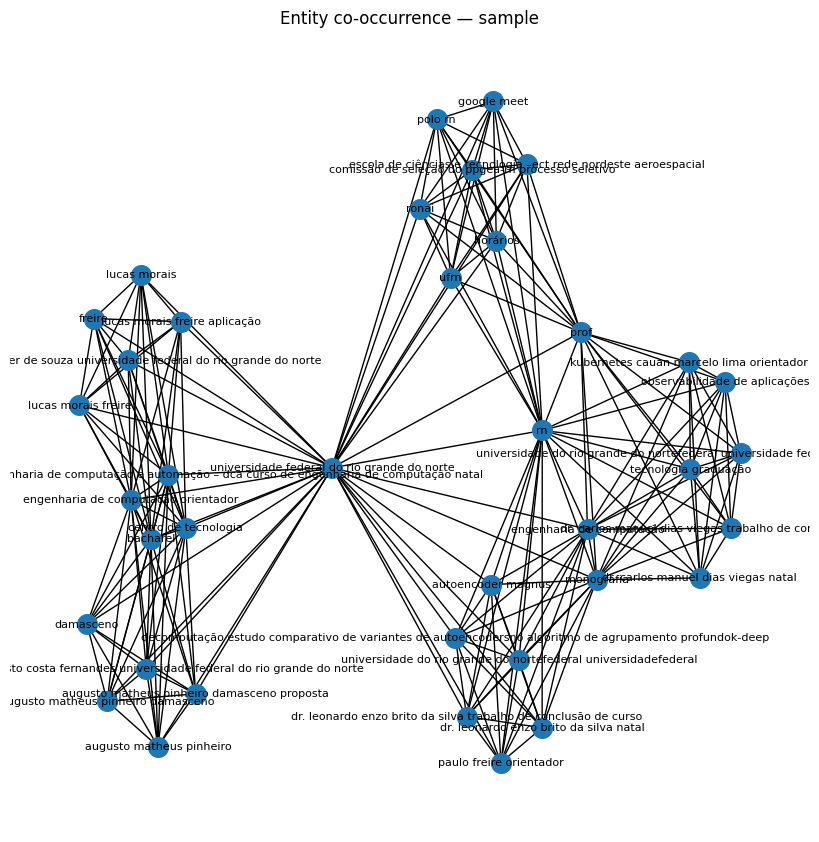

In [21]:
# Build graph by re-reading the JSONL we just created (safe and incremental)
G = nx.Graph()
if ENTITIES_JSONL.exists():
    with ENTITIES_JSONL.open("r", encoding="utf-8") as f:
        for line in f:
            try:
                item = json.loads(line)
                ents = item.get("entities", [])
            except Exception:
                continue
            if len(ents) < 2:
                continue
            for e in ents:
                if not G.has_node(e):
                    G.add_node(e, entity=e, document_count=0)
                G.nodes[e]["document_count"] += 1
            for a, b in combinations(sorted(ents), 2):
                if G.has_edge(a, b):
                    G[a][b]["weight"] += 1
                else:
                    G.add_edge(a, b, weight=1)

print(f"Graph built — nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

# Simple draw if small
if G.number_of_nodes() <= 50 and G.number_of_nodes() > 0:
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=200, font_size=8)
    plt.title("Entity co-occurrence — sample")
    out_svg = OUTPUT_DIR / "graph_sample.svg"
    plt.savefig(out_svg, format="svg")
    print(f"Saved small graph preview to {out_svg}")
else:
    print("Graph too large to draw a full preview; saved GEXF below")

# save GEXF using integer node ids (Gephi-friendly) and preserve UTF-8 characters
gexf_path = OUTPUT_DIR / "graph.gexf"
mapping = {n: i for i, n in enumerate(G.nodes())}
H = nx.relabel_nodes(G, mapping, copy=True)
for new_id, data in H.nodes(data=True):
    original = data.get("entity") if data.get("entity") else next((o for o, v in mapping.items() if v == new_id), str(new_id))
    H.nodes[new_id]["label"] = original
    H.nodes[new_id]["entity"] = original

# generate full content, then replace numeric XML refs with real UTF-8 chars
content = "".join(nx.generate_gexf(H))
content = re.sub(r"&#(\d+);", lambda m: chr(int(m.group(1))), content)
content = re.sub(r"&#x([0-9a-fA-F]+);", lambda m: chr(int(m.group(1), 16)), content)
if not content.lstrip().startswith("<?xml"):
    content = "<?xml version=\"1.0\" encoding=\"utf-8\"?>\n" + content
with gexf_path.open("w", encoding="utf-8") as f:
    f.write(content)
print(f"GEXF saved to {gexf_path}")

## Stage 5 — Single-pass segmentation analysis (limited)

Run a single-pass segmentation analysis over the `records` already loaded. This uses sentence, paragraph and k-char strategies and does not re-run the full NLP pipeline for each segment.

In [18]:
def analyze_segmentation_single_pass(records: Iterable[Dict[str, Any]], nlp) -> Dict[str, Any]:
    strategies = ("sentence", "paragraph", "k_chars")
    accum = {name: {"documents_processed": 0, "segments_total": 0, "segments_with_entities": 0, "total_entities": 0, "unique_entities": set(), "processing_time_seconds": 0.0} for name in strategies}

    for rec in records:
        text = rec.get("text", "")
        if not text:
            continue
        doc = nlp(text)
        sentence_segments = [s.text.strip() for s in getattr(doc, "sents", []) if s.text.strip()]
        paragraph_segments = segment_text_by_paragraph(text)
        kchar_segments = segment_text_by_char_blocks(text, CHAR_BLOCK_SIZE)
        segments_map = {"sentence": sentence_segments, "paragraph": paragraph_segments, "k_chars": kchar_segments}
        for name, segments in segments_map.items():
            start = time.perf_counter()
            accum[name]["documents_processed"] += 1
            accum[name]["segments_total"] += len(segments)
            for seg in segments:
                seg_lower = seg.lower()
                entities_in_seg = {ent.text.strip().lower() for ent in getattr(doc, "ents", []) if ent.text and ent.text.strip() and ent.text.strip().lower() in seg_lower}
                if not entities_in_seg:
                    continue
                accum[name]["segments_with_entities"] += 1
                accum[name]["total_entities"] += len(entities_in_seg)
                accum[name]["unique_entities"].update(entities_in_seg)
            accum[name]["processing_time_seconds"] += time.perf_counter() - start

    results: Dict[str, Any] = {}
    for name in strategies:
        d = accum[name]
        results[name] = {
            "documents_processed": d["documents_processed"],
            "segments_total": d["segments_total"],
            "segments_with_entities": d["segments_with_entities"],
            "total_entities": d["total_entities"],
            "unique_entities": len(d["unique_entities"]),
            "avg_entities_per_segment": round(d["total_entities"]/d["segments_with_entities"],3) if d["segments_with_entities"] else 0.0,
            "processing_time_seconds": round(d["processing_time_seconds"],3),
            "character_block_size": CHAR_BLOCK_SIZE if name=="k_chars" else None
        }
    return results

# run the analysis on our limited records (if any)
if records:
    metrics = analyze_segmentation_single_pass(records, nlp)
    print(json.dumps(metrics, ensure_ascii=False, indent=2))
    with PERF_METRICS.open("w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)
    print(f"Saved performance metrics to {PERF_METRICS}")
else:
    print("No records available for segmentation analysis (increase FILE_LIMIT or add PDFs to data/raw)")

{
  "sentence": {
    "documents_processed": 5,
    "segments_total": 2143,
    "segments_with_entities": 1998,
    "total_entities": 18708,
    "unique_entities": 1834,
    "avg_entities_per_segment": 9.363,
    "processing_time_seconds": 12.961,
    "character_block_size": null
  },
  "paragraph": {
    "documents_processed": 5,
    "segments_total": 5,
    "segments_with_entities": 5,
    "total_entities": 1958,
    "unique_entities": 1836,
    "avg_entities_per_segment": 391.6,
    "processing_time_seconds": 0.063,
    "character_block_size": null
  },
  "k_chars": {
    "documents_processed": 5,
    "segments_total": 550,
    "segments_with_entities": 550,
    "total_entities": 11545,
    "unique_entities": 1795,
    "avg_entities_per_segment": 20.991,
    "processing_time_seconds": 3.533,
    "character_block_size": 500
  }
}
Saved performance metrics to /home/joaod/projects/py/graph-ner/data/processed/performance_metrics.json


## Stage 6 — Save results, checkpoints and notes

This final stage lists the produced files and explains how to change `FILE_LIMIT` or run the full pipeline from `main.py`.

In [19]:
# Defaults already defined in the Setup cell above.
# If you want to change MODEL_CANDIDATES or FILE_LIMIT, edit the Setup cell (Cell 1) and re-run it.
print(f"MODEL_CANDIDATES: {MODEL_CANDIDATES}, FILE_LIMIT: {FILE_LIMIT}")

MODEL_CANDIDATES: ['pt_core_news_lg', 'pt_core_news_sm'], FILE_LIMIT: 5


In [20]:
# Entity extraction using PT-BR defaults and per-document caps
# This cell uses `nlp`, `ENTITIES_PER_DOC`, `FILE_LIMIT` and `FILTER_LABELS` defined above.
if 'nlp' not in globals():
    nlp = get_nlp()

# clear previous entities file for a clean run
if ENTITIES_JSONL.exists():
    ENTITIES_JSONL.unlink()

if 'records' not in globals() or not records:
    print("No records found. Run Stage 2 (Extract text) first to populate `records`.")
else:
    for rec in records[:FILE_LIMIT]:
        doc = nlp(rec['text'])
        ents = extract_limited_entities_from_doc(doc, max_entities=ENTITIES_PER_DOC, filter_labels=FILTER_LABELS)
        append_entities_jsonl(rec['id'], ents, ENTITIES_JSONL)
        print(f"{rec['id']}: {len(ents)} entities (limited to {ENTITIES_PER_DOC})")

    print(f"Entities appended to {ENTITIES_JSONL}")

AplicaçãoDeEstencilsCompactos_Freire_2025: 10 entities (limited to 10)
Arquitetura_de_Monitoramento_e_Observabilidade_de_Aplicações_em_Kubernetes (13): 10 entities (limited to 10)
Augusto Damasceno - TCC - Pub: 10 entities (limited to 10)
EstudoComparativoVariantes_Freire_2025: 10 entities (limited to 10)
Hora769rios_e_dias_da_arguic807a771o_oral_-_Polo_RN: 10 entities (limited to 10)
Entities appended to /home/joaod/projects/py/graph-ner/data/processed/entities.jsonl
